In [1]:
import pandas as pd
df = pd.read_csv("SampleSuperstore.csv")


In [2]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [3]:
df.columns


Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [4]:
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [5]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ship_mode     9994 non-null   object 
 1   segment       9994 non-null   object 
 2   country       9994 non-null   object 
 3   city          9994 non-null   object 
 4   state         9994 non-null   object 
 5   postal_code   9994 non-null   int64  
 6   region        9994 non-null   object 
 7   category      9994 non-null   object 
 8   sub_category  9994 non-null   object 
 9   sales         9994 non-null   float64
 10  quantity      9994 non-null   int64  
 11  discount      9994 non-null   float64
 12  profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [6]:
df.isna().sum().sort_values

<bound method Series.sort_values of ship_mode       0
segment         0
country         0
city            0
state           0
postal_code     0
region          0
category        0
sub_category    0
sales           0
quantity        0
discount        0
profit          0
dtype: int64>

In [7]:
df.describe()

,postal_code,sales,quantity,discount,profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
# Total sales and profit
df[["sales", "profit"]].sum()

# Sales by category
df.groupby("category")["sales"].sum().sort_values(ascending=False)

# Profit by category
df.groupby("category")["profit"].sum().sort_values(ascending=False)

# Top 10 categories by sales
df.groupby("category")["sales"].sum().sort_values(ascending=False).head(10)


category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: sales, dtype: float64

In [15]:
"""
Answering business questions with data

# Sales Performance by Category

The analysis shows how total sales are distributed across product categories:

Technology generates the highest total sales, with approximately $836K, making it the strongest-performing category.

Furniture follows with about $742K in total sales, indicating solid demand but lower performance compared to Technology.

Office Supplies records the lowest sales among the three categories, at approximately $719K, though it remains a significant contributor overall.

# Key Insight

Technology is the primary revenue driver for the business. This suggests that investing more in technology products—through marketing, inventory expansion, or promotions—could further increase overall sales performance. Furniture and Office Supplies may require targeted strategies to close the gap.
"""

'\nAnswering business questions with data\n\n# Sales Performance by Category\n\nThe analysis shows how total sales are distributed across product categories:\n\nTechnology generates the highest total sales, with approximately $836K, making it the strongest-performing category.\n\nFurniture follows with about $742K in total sales, indicating solid demand but lower performance compared to Technology.\n\nOffice Supplies records the lowest sales among the three categories, at approximately $719K, though it remains a significant contributor overall.\n\n# Key Insight\n\nTechnology is the primary revenue driver for the business. This suggests that investing more in technology products—through marketing, inventory expansion, or promotions—could further increase overall sales performance. Furniture and Office Supplies may require targeted strategies to close the gap.\n'

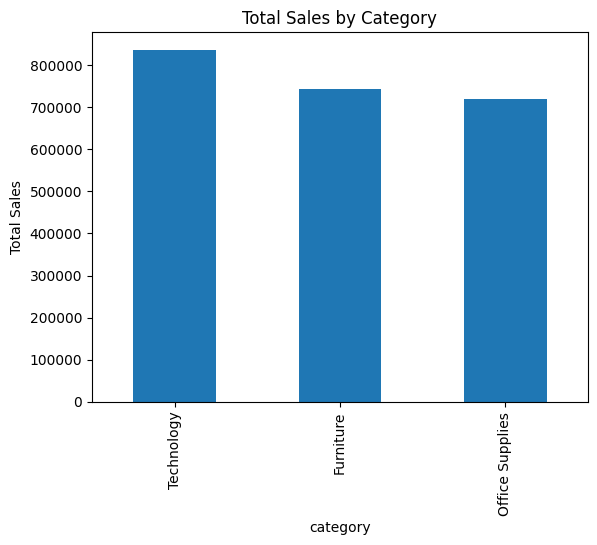

In [12]:
import matplotlib.pyplot as plt
df.groupby("category")["sales"].sum().sort_values(ascending=False).plot(kind="bar")
plt.ylabel("Total Sales")
plt.title("Total Sales by Category")    
plt.show()


# Key Insights from Initial Data Exploration

The dataset contains 9,994 sales transactions with no missing values, indicating strong data quality and minimal need for preprocessing.

Technology is the top-performing category by total sales, making it the primary revenue driver for the business.

Furniture and Office Supplies generate comparable sales volumes but lag behind Technology, suggesting potential opportunities for targeted growth strategies.

The presence of negative profit values (despite positive sales) indicates that some products or orders are being sold at a loss, likely due to high discounts or low margins.

Sales and profit data are well-suited for category-level, regional, and customer-segment analysis, enabling deeper business insights.

The balanced mix of categorical and numerical variables allows for meaningful segmentation and performance comparison across products and regions.

# Business Implications

Investing in high-performing Technology products could maximize revenue growth.

Loss-making transactions should be analyzed further to understand the impact of discounting strategies on profitability.

Since the data is clean and complete, the focus can shift toward advanced analysis and visualization rather than data cleaning.

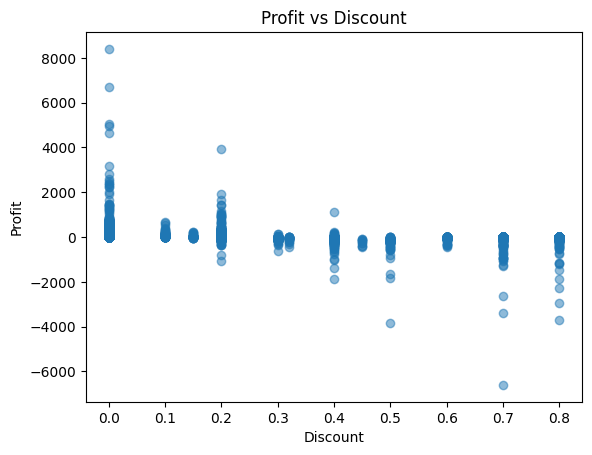

In [20]:
plt.scatter(df["discount"], df["profit"], alpha=0.5)
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Profit vs Discount")
plt.show()

In [21]:
# average profit by discount rate
df.groupby("discount")["profit"].mean().sort_index()

discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: profit, dtype: float64

In [23]:
# Sales by region
df.groupby("region")["sales"].sum().sort_values(ascending=False)


region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: sales, dtype: float64

In [26]:
# Profit by region
df.groupby("region")["profit"].sum().sort_values(ascending=False).round(2)


region
West       108418.45
East        91522.78
South       46749.43
Central     39706.36
Name: profit, dtype: float64

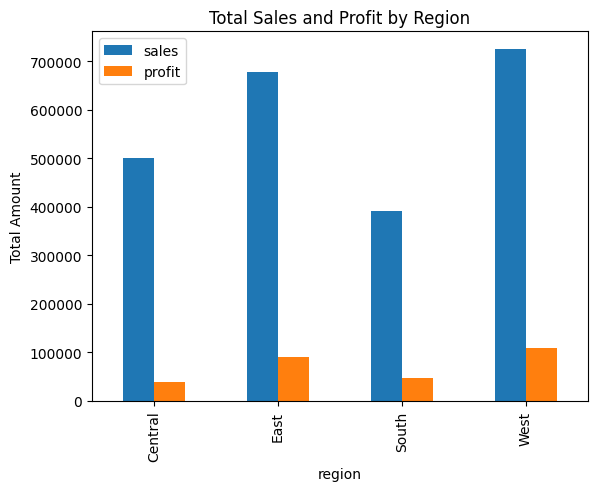

In [27]:
df.groupby("region")[["sales", "profit"]].sum().plot(kind="bar")
plt.ylabel("Total Amount")
plt.title("Total Sales and Profit by Region")    
plt.show()  

In [30]:
# Profit by category and sub-category
df.groupby(["category", "sub_category"])["profit"].sum().sort_values().round(2)

category         sub_category
Furniture        Tables         -17725.48
                 Bookcases       -3472.56
Office Supplies  Supplies        -1189.10
                 Fasteners         949.52
Technology       Machines         3384.76
Office Supplies  Labels           5546.25
                 Art              6527.79
                 Envelopes        6964.18
Furniture        Furnishings     13059.14
Office Supplies  Appliances      18138.01
                 Storage         21278.83
Furniture        Chairs          26590.17
Office Supplies  Binders         30221.76
                 Paper           34053.57
Technology       Accessories     41936.64
                 Phones          44515.73
                 Copiers         55617.82
Name: profit, dtype: float64

In [32]:
# Top loss making sub-categories
df.groupby("sub_category")["profit"].sum().sort_values().head(10).round(2)


sub_category
Tables        -17725.48
Bookcases      -3472.56
Supplies       -1189.10
Fasteners        949.52
Machines        3384.76
Labels          5546.25
Art             6527.79
Envelopes       6964.18
Furnishings    13059.14
Appliances     18138.01
Name: profit, dtype: float64

## Key Insights – Profitability & Regional Analysis

- Higher discount levels are associated with declining profitability, with several high-discount transactions resulting in losses.
- The **West** region generates the highest sales and profit, making it the strongest-performing region.
- Some regions generate strong sales but lower profit, indicating cost or discount inefficiencies.
- Several sub-categories consistently operate at a loss, highlighting opportunities for pricing or inventory optimization.


In [35]:
# Identify high risk orders
df[df["profit"] < 0].shape
df[df["profit"] < 0].head()

,ship_mode,segment,country,city,state,postal_code,region,category,sub_category,sales,quantity,discount,profit
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
14,Standard Class,Home Office,United States,Fort Worth,Texas,76106,Central,Office Supplies,Appliances,68.8100,5,0.80,-123.8580
15,Standard Class,Home Office,United States,Fort Worth,Texas,76106,Central,Office Supplies,Binders,2.5440,3,0.80,-3.8160
23,Second Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Furniture,Chairs,71.3720,2,0.30,-1.0196
27,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Furniture,Bookcases,3083.4300,7,0.50,-1665.0522


In [36]:
# by category
df[df["profit"] < 0].groupby("category")["profit"].count()


category
Furniture          714
Office Supplies    886
Technology         271
Name: profit, dtype: int64

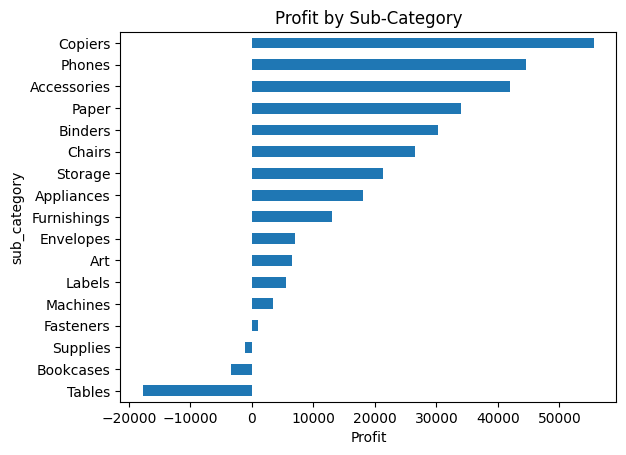

sub_category
Labels         0.068681
Storage        0.074704
Art            0.074874
Paper          0.074891
Supplies       0.076842
Accessories    0.078452
Envelopes      0.080315
Fasteners      0.082028
Furnishings    0.138349
Phones         0.154556
Copiers        0.161765
Appliances     0.166524
Chairs         0.170178
Bookcases      0.211140
Tables         0.261285
Machines       0.306087
Binders        0.372292
Name: discount, dtype: float64

In [37]:
df.groupby("sub_category")["profit"].sum().sort_values().plot(kind="barh")
plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.show()
# average discount by sub-category
df.groupby("sub_category")["discount"].mean().sort_values()


## Executive Summary

This project analyzes retail sales performance to identify revenue drivers, profitability risks, and optimization opportunities across products, customers, and regions.

### Key Findings
- Technology is the strongest revenue and profit driver.
- Discount-heavy transactions are strongly associated with negative profitability.
- Several sub-categories consistently operate at a loss.
- The Consumer segment contributes the highest overall profit.
- Profitability varies significantly across regions and product categories.

### Recommendations
- Focus investment on high-margin Technology products.
- Re-evaluate discount strategies to reduce loss-making sales.
- Optimize or restructure underperforming sub-categories.
- Use profit margin analysis to guide pricing and promotional decisions.
